In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vigne\Desktop\JOB\jobacceptancespredictionsystem\HR_Job_Placement_Dataset.csv")
df.head()
df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='object')

In [21]:
df.shape

(51500, 26)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

Checking Missing Values

In [23]:
df.isnull().sum().sort_values(ascending=False)

relocation_willingness       8475
layoff_history               8467
career_switch_willingness    8466
relevant_experience          8426
job_role_match               6131
ssc_percentage               2581
hsc_percentage               2065
notice_period_days           1582
employment_gap_months        1097
gender                          0
skills_match_percentage         0
communication_score             0
aptitude_score                  0
technical_score                 0
degree_specialization           0
degree_percentage               0
age_years                       0
internship_experience           0
company_tier                    0
expected_ctc_lpa                0
previous_ctc_lpa                0
years_of_experience             0
certifications_count            0
competition_level               0
bond_requirement                0
status                          0
dtype: int64

Checking Target Variables

In [24]:
df['status'].value_counts()

status
Not Placed    35921
Placed        15579
Name: count, dtype: int64

Check Catogorical Columns

In [25]:
df.select_dtypes(include='object').columns

Index(['gender', 'degree_specialization', 'internship_experience',
       'career_switch_willingness', 'relevant_experience', 'company_tier',
       'job_role_match', 'competition_level', 'bond_requirement',
       'layoff_history', 'relocation_willingness', 'status'],
      dtype='object')

Sample Unique Values

In [26]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique()[:10])


gender
['Male' 'Female' 'female' 'male']

degree_specialization
['Computer Science' 'Electronics' 'Information Technology' 'Mechanical'
 'Others']

internship_experience
['No' 'yes ' 'Yes' ' no']

career_switch_willingness
['Willing' 'Not Willing' nan]

relevant_experience
['Relevant' 'Not Relevant' nan]

company_tier
['Tier 3' 'Tier 1' 'Tier 2' 'Tier 2 ' 'Tier 3 ' 'Tier 1 ']

job_role_match
['Not Matched' 'Matched' nan]

competition_level
['Medium' 'High' 'Low']

bond_requirement
['Not Required' 'Required']

layoff_history
['No' nan 'Yes']

relocation_willingness
['Not Willing' nan 'Willing']

status
['Not Placed' 'Placed']


In [27]:
df.describe()

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,51500.000000,48919.000000,49435.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,49918.000000,50403.000000
mean,27.505456,70.002505,72.060636,74.010825,68.027499,64.005715,66.106692,73.937491,1.400136,1.494117,4.844616,8.002649,20.095457,3.056187
std,4.025385,7.976314,7.916654,6.945579,11.855145,9.922397,9.907488,11.794258,1.184387,1.375508,2.125294,3.133792,24.852660,4.431784
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.574733,66.720058,69.305041,59.935988,57.204237,59.252271,65.851924,1.000000,0.000000,3.325635,5.672655,0.000000,0.000000
50%,27.000000,69.971210,72.014383,73.998187,67.986042,63.972079,66.033268,74.001772,1.000000,1.000000,4.807598,7.857337,15.000000,0.000000
75%,31.000000,75.389057,77.389894,78.707827,76.049235,70.727134,72.840985,82.112773,2.000000,2.000000,6.297570,10.093509,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,8.000000,5.000000,13.844566,26.524634,90.000000,18.000000


Data Cleaning and Preprocessing

Handle Missing Values
Categorical Columns → Mode

In [28]:
at_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

NameError: name 'cat_cols' is not defined

Numerical Columns Median

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
df.isnull().sum()

age_years                       0
gender                          0
ssc_percentage               2581
hsc_percentage               2065
degree_percentage               0
degree_specialization           0
technical_score                 0
aptitude_score                  0
communication_score             0
skills_match_percentage         0
certifications_count            0
internship_experience           0
years_of_experience             0
career_switch_willingness    8466
relevant_experience          8426
previous_ctc_lpa                0
expected_ctc_lpa                0
company_tier                    0
job_role_match               6131
competition_level               0
bond_requirement                0
notice_period_days           1582
layoff_history               8467
employment_gap_months        1097
relocation_willingness       8475
status                          0
dtype: int64

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
df.isnull().sum()

age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64

EDA

1. Interview / Technical Score

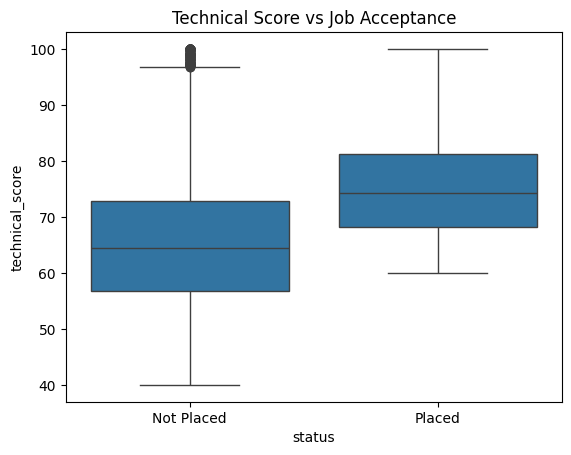

In [ ]:
sns.boxplot(x='status', y='technical_score', data=df)
plt.title("Technical Score vs Job Acceptance")
plt.show()

2. Communication Score

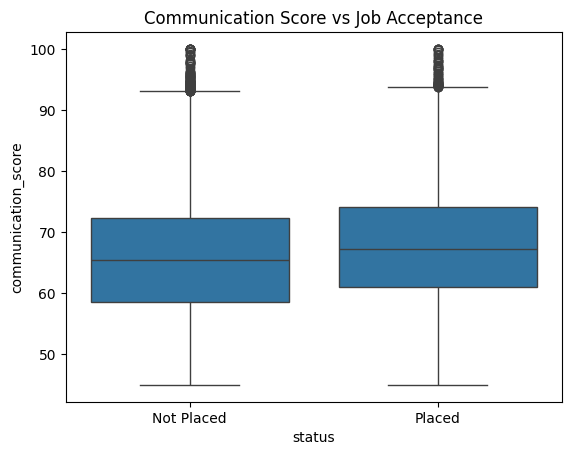

In [ ]:
sns.boxplot(x='status', y='communication_score', data=df)
plt.title("Communication Score vs Job Acceptance")
plt.show()

3. Skills Match

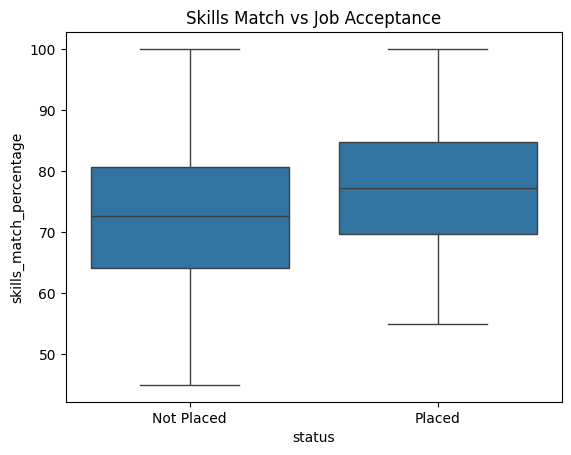

In [ ]:
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title("Skills Match vs Job Acceptance")
plt.show()

4. Experience

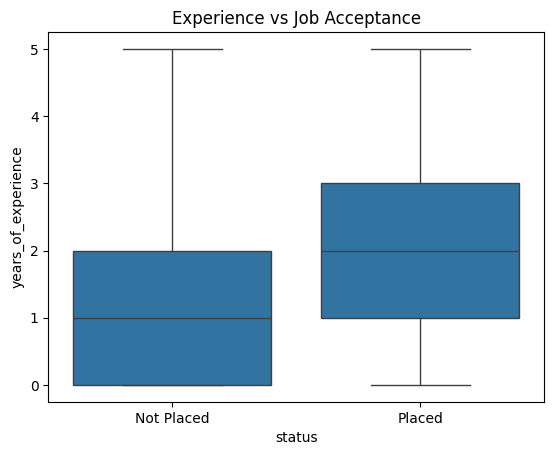

In [ ]:
sns.boxplot(x='status', y='years_of_experience', data=df)
plt.title("Experience vs Job Acceptance")
plt.show()

Feature Engineering

Experience Category

In [ ]:
df['experience_category'] = pd.cut(
    df['years_of_experience'],
    bins=[-1, 1, 3, 10],
    labels=['Fresher', 'Junior', 'Senior']
)

Academic Performance Bands

In [ ]:
df['academic_performance'] = pd.cut(
    df['degree_percentage'],
    bins=[0, 60, 75, 100],
    labels=['Low', 'Average', 'High']
)

Skills Match Level

In [ ]:
df['skills_level'] = pd.cut(
    df['skills_match_percentage'],
    bins=[0, 50, 75, 100],
    labels=['Low', 'Medium', 'High']
)

Interview Performance Category

In [ ]:
df['interview_performance'] = pd.cut(
    df['technical_score'],
    bins=[0, 60, 75, 100],
    labels=['Poor', 'Average', 'Good']
)

Placement Probability Score

In [ ]:
df['placement_score'] = (
    0.4 * df['technical_score'] +
    0.3 * df['communication_score'] +
    0.3 * df['skills_match_percentage']
)

Encoding

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.shape

(51500, 47)

In [ ]:
print(df.columns)

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months', 'placement_score',
       'gender_Male', 'gender_female', 'gender_male',
       'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'internship_experience_No', 'internship_experience_Yes',
       'internship_experience_yes ', 'career_switch_willingness_Willing',
       'relevant_experience_Relevant', 'company_tier_Tier 1 ',
       'company_tier_Tier 2', 'company_tier_Tier 2 ', 'company_tier_Tier 3',
       'company_tier_Tier 3 ', 'job_role_match_Not Matched',
       'competition_level_Low', 'competition_level_Medium',
       'bond_requirement_Req

MACHINE LEARNING MODEL

Split Data

In [ ]:
y = df['status_Placed']
X = df.drop('status_Placed', axis=1)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
[col for col in df.columns if 'status' in col]

['status_Placed']

In [ ]:
y_pred = model.predict(X_test)

Accuracy


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8860194174757282
              precision    recall  f1-score   support

       False       0.90      0.94      0.92      7128
        True       0.85      0.76      0.81      3172

    accuracy                           0.89     10300
   macro avg       0.87      0.85      0.86     10300
weighted avg       0.88      0.89      0.88     10300



In [ ]:
import pickle

# Save model
pickle.dump(model, open('model.pkl', 'wb'))

# Save column structure
pickle.dump(X.columns, open('columns.pkl', 'wb'))

NameError: name 'model' is not defined

In [29]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_csv("HR_Job_Placement_Dataset.csv")

# Handle missing values
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Feature engineering
df['experience_category'] = pd.cut(df['years_of_experience'], bins=[-1,1,3,10],
                                  labels=['Fresher','Junior','Senior'])

df['skills_level'] = pd.cut(df['skills_match_percentage'], bins=[0,50,75,100],
                           labels=['Low','Medium','High'])

df['interview_performance'] = pd.cut(df['technical_score'], bins=[0,60,75,100],
                                    labels=['Poor','Average','Good'])

df['placement_score'] = (
    0.4*df['technical_score'] +
    0.3*df['communication_score'] +
    0.3*df['skills_match_percentage']
)

# Encoding
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop('status_Placed', axis=1)
y = df['status_Placed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save files
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(X.columns, open('columns.pkl', 'wb'))

print("✅ DONE — model.pkl created")

✅ DONE — model.pkl created


In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,   # fewer trees (smaller size)
    max_depth=10,      # limit complexity
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [31]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(X.columns, open('columns.pkl', 'wb'))

print("✅ Optimized model saved")

✅ Optimized model saved


In [32]:
import os
print(os.path.getsize("model.pkl") / (1024*1024), "MB")

3.617180824279785 MB


 Key Insights

 Technical Score is the strongest predictor of job acceptance. Candidates with higher technical scores are significantly more likely to be placed.

 Communication skills play a crucial role in hiring decisions. Candidates with better communication scores show higher placement success.

 Skills Match Percentage has a major impact on job acceptance. Higher alignment between candidate skills and job requirements increases the probability of placement.

 Experience contributes positively, but it is not the only deciding factor. Even freshers can get placed if they have strong technical and communication skills.

 Class imbalance is present in the dataset, with more "Not Placed" candidates than "Placed", which slightly influences model predictions.

 Feature engineering improved model performance, especially with the creation of the `placement_score`, which combines multiple performance indicators.

 Job role alignment and company tier influence placement, indicating that better job fit leads to higher acceptance rates.



 Conclusion

 The analysis reveals that technical skills, communication ability, and skill-job alignment are the most important factors influencing job acceptance. While experience plays a supporting role, strong skills can compensate for lower experience levels. The model effectively captures these patterns and provides reliable predictions for recruitment decision-making.



 Business Impact

 Helps recruiters identify high-potential candidates early  
 Reduces offer rejection rates  
 Improves hiring efficiency  
 Supports data-driven decision-making  